# **Data Science Challenge - Clustering Driver Behaviour & Model Evaluation** 

|  |  |
|:---|:---|
|**Full Name** | Kingsley Ohere  |
|**Skills Demonstrated** | Python, Clustering, Dimensionality Reduction (PCA)
|**Section** | Driver Behaviour |

---

In [ ]:
import os
import sys
import yaml

# Make src/ importable from the notebook
sys.path.insert(0, os.path.abspath(".."))   # adds repo root so "from src.X import Y" resolves

# Load all project settings from config.yaml
with open("../config.yaml", "r") as _f:
    cfg = yaml.safe_load(_f)

print("Config loaded. Data path:", cfg['data']['path'])


Config loaded. Data path: ../data/driver_behavior.csv


## **Exercise 1: Driver Behaviour**

**Exercise information:** An auto-insurance company is revamping its pricing model. The analyst developing the new price model 
believes that the best approach is to develop several models based on groups of similar drivers. You have been contracted to develop a model to define groups of drivers based on driving behavior. The analyst has prepared a dataset (driver_behavior.csv) consisting of 10,000 customers and 5 engineered features which capture driving behavior. The data has already been preprocessed for you (i.e., no missing data, no outliers, data is scaled, and no correlated features)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv(cfg['data']['path'])
print(df.shape)
df.head()

(10000, 5)


,FAXEX,BCACE,DBBAB,AAXFE,BXCEC
0,-0.893210,-2.080530,1.581359,-0.739197,-0.115923
1,-0.279951,2.575102,0.329756,0.248520,0.324917
2,-3.898434,-0.024275,-1.728197,4.992603,2.395236
3,-3.120864,-3.031472,-0.021979,2.755907,1.216255
4,-1.049326,0.953137,-1.905779,-1.566512,2.589435


**Exercise 1:** Develop a model to group the drivers and comment on the quality of the generated groups using an 
appropriate metric or visualization. How many different groups of drivers did you create from the 
provided data? 
In addition to submitting your code, please explain the decisions you made.

In [ ]:
X = df.copy()

In [ ]:
# Determine optimal number of clusters using Elbow Plot Method and Silhouette Score
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={silhouette_scores[-1]:.3f}")

K=2: Inertia=90344.12, Silhouette Score=0.324
K=3: Inertia=73286.03, Silhouette Score=0.280
K=4: Inertia=63193.44, Silhouette Score=0.258
K=5: Inertia=54606.12, Silhouette Score=0.248
K=6: Inertia=49590.22, Silhouette Score=0.249
K=7: Inertia=45397.28, Silhouette Score=0.249
K=8: Inertia=42610.87, Silhouette Score=0.244
K=9: Inertia=39943.41, Silhouette Score=0.247
K=10: Inertia=37397.96, Silhouette Score=0.227


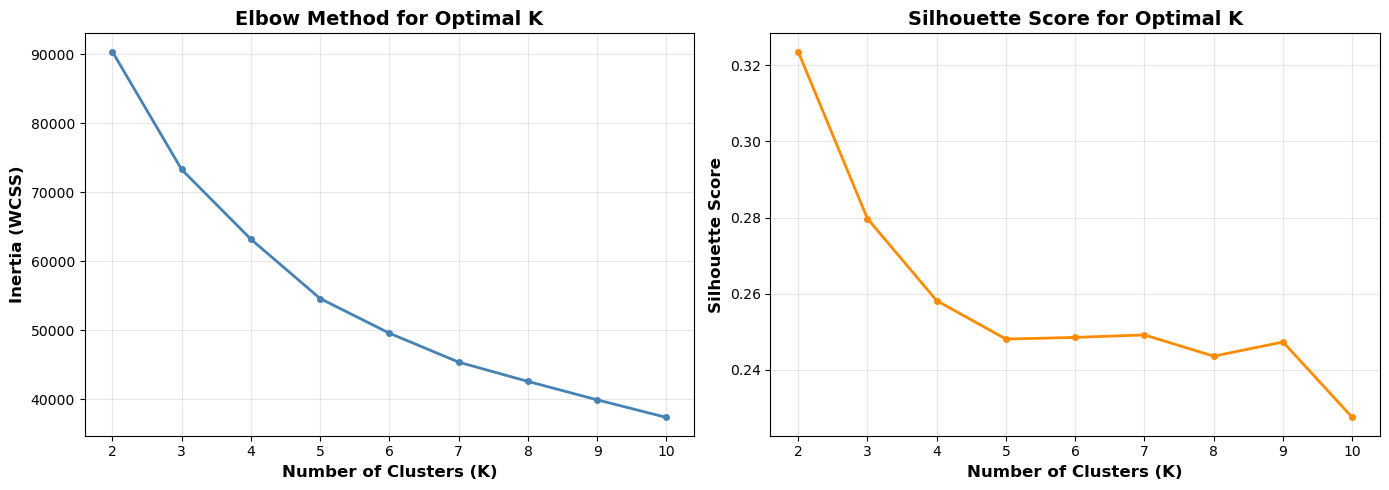

In [ ]:
# Plot Elbow Method and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(K_range, inertias, marker='.', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, marker='.', linewidth=2, markersize=8, color='darkorange')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Score for Optimal K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Cluster Validation Methods

### 1. Elbow Method

The Elbow Method helps identify the number of clusters (k) by examining how the inertia (within-cluster sum of squares, WCSS) decreases as k increases.

$$
\text{Inertia} = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2
$$

* $C_i$ = cluster i
* $\mu_i$ = centroid of cluster i
* $x$ = data points

We look for a point where the decrease in inertia slows down (the "elbow").

From the plot, there is a sharp drop up to k=5. After k=5, the curve flattens suggesting the optimal k is 5

### 2. Silhouette Method

The Silhouette Score measures how similar a point is to its own cluster compared to other clusters. It ranges from -1 to 1.

* **+1** = well clustered
* **0** = on the boundary
* **-1** = misclassified

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

* $a(i)$: average distance of point i to other points in the **same cluster**
* $b(i)$: average distance of point i to points in the **nearest cluster**

From the plot, the highest silhouette is at k=2 (0.324), but also reasonably good at k=3 (0.28). The score declines after k=5


In [ ]:
# We'll be ploting from 2 up to 5 so we can conpare the results of each.
for k in [2,3,4,5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    print(f"\nResults for k={k}:")
    print(f"  Silhouette Score      : {sil:.4f}")
    print(f"  Davies–Bouldin Index  : {dbi:.4f}")
    print(f"  Calinski–Harabasz     : {ch:.4f}")


Results for k=2:
  Silhouette Score      : 0.3235
  Davies–Bouldin Index  : 1.2377
  Calinski–Harabasz     : 5706.1532

Results for k=3:
  Silhouette Score      : 0.2799
  Davies–Bouldin Index  : 1.2748
  Calinski–Harabasz     : 4679.9812

Results for k=4:
  Silhouette Score      : 0.2586
  Davies–Bouldin Index  : 1.3497
  Calinski–Harabasz     : 4149.8047

Results for k=5:
  Silhouette Score      : 0.2481
  Davies–Bouldin Index  : 1.3302
  Calinski–Harabasz     : 3994.8629


**Interpretation**

1. **Silhouette Score (higher is better; range -1 to 1)**

* k=2 → **0.3235** (highest)
* k=3 → 0.2799
* k=4 → 0.2586
* k=5 → 0.2481

Interpretation: clusters are most compact and well separated at k=2.

2. **Davies–Bouldin Index (lower is better; minimum = ideal)**

* k=2 → **1.2377** (lowest
* k=3 → 1.2748
* k=4 → 1.3497
* k=5 → 1.3302

Interpretation: cluster separation and compactness are best at k=2.

3. **Calinski–Harabasz Index (higher is better)**

* k=2 → **5706.15** (highest
* k=3 → 4679.98
* k=4 → 4149.80
* k=5 → 3994.86

Interpretation: clusters are most distinct at k=2.

**Overall Best k**

All three metrics agree that **k=2** is the best choice for the dataset: highest Silhouette score, lowest Davies–Bouldin Index, and highest Calinski–Harabasz Index.

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


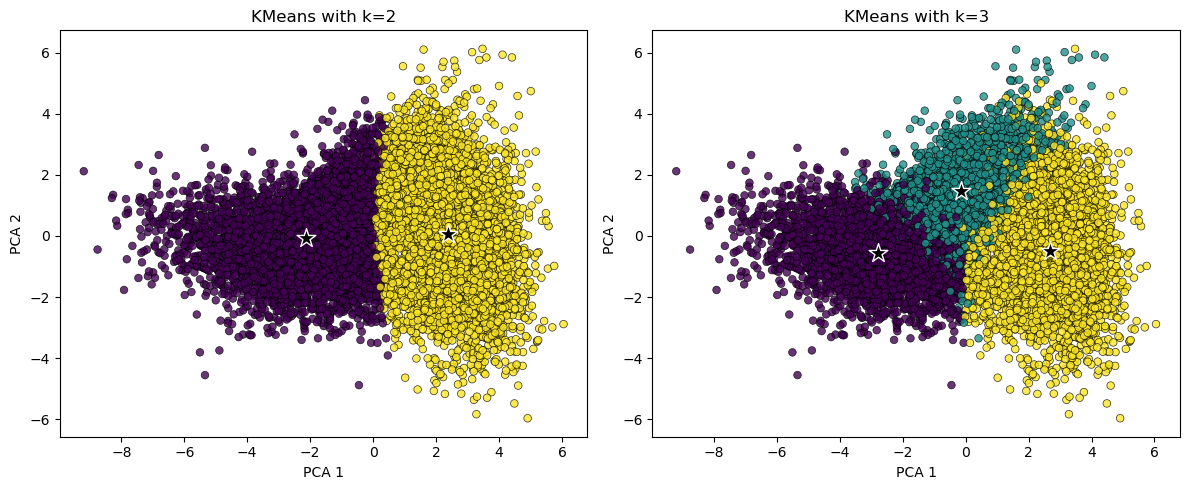

In [ ]:
# Assume X is your data (NumPy array or DataFrame)
# Reduce data to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, k in zip(axes, [2, 3]):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    centers = pca.transform(kmeans.cluster_centers_)  # project centroids into PCA space

    # Scatter plot of points
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=30, alpha=0.8, edgecolors='k', linewidth=0.5)
    # Plot centroids
    ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='*', edgecolors='white', linewidths=1)

    ax.set_title(f"KMeans with k={k}")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.tight_layout()
plt.show();

**Excerise 1 Answer:** I create two instances one where K = 2 and another where K = 3.

With k = 2, the data divides cleanly into two large, well-separated groups along the first principal component. The clusters are distinct and balanced, which aligns with the strong performance of the internal validity metrics. However, this binary split risks oversimplifying the structure of the data by grouping all variation into just two categories.

At k = 3, a third cluster emerges in the upper-central region, capturing points that were previously absorbed into the larger groups. This segmentation introduces nuance, suggesting the presence of an intermediate behavioral pattern. While the additional cluster overlaps somewhat with the others explaining the weaker metrics. It offers a richer, more interpretable view that may correspond to a middle ground between conservative and aggressive behaviors

**Explanation behind reasoning:** The clustering validity metrics indicate that k = 2 is the most appropriate choice. At two clusters, the solution achieved the highest Silhouette Score (0.3235), the lowest Davies–Bouldin Index (1.2377), and the highest Calinski–Harabasz Index (5706.15), reflecting compact and well separated groupings.

The Elbow Method, however, shows a visible inflection around k = 3–4, where the rate of inertia reduction begins to slow. This suggests that while additional clusters improve model fit, the marginal gains diminish beyond three clusters.

The PCA visualizations reinforce this trade-off. With k = 2, the data forms two clear and balanced groups, but the binary split may oversimplify underlying variation. At k = 3, a third cluster emerges, capturing a subgroup of points that were previously absorbed into the larger clusters. Although this solution has weaker internal metrics, it provides a more nuanced segmentation potentially reflecting conservative, moderate, and aggressive driving styles which may be more valuable for interpretation and practical application.

**In summary**, while two clusters maximize statistical validity, the three-cluster solution may better capture meaningful behavioral distinctions, depending on whether the priority is methodological rigor or actionable insight.


---

## Algorithm Comparison: K-Means vs DBSCAN vs Agglomerative Hierarchical

This section extends the analysis beyond K-Means to evaluate two additional
clustering paradigms. The goal is to demonstrate that K-Means was selected
deliberately — not by default — based on the structure and business context
of this dataset.

### DBSCAN — Density-Based Spatial Clustering of Applications with Noise

DBSCAN does not require specifying the number of clusters in advance.
It identifies clusters as dense regions separated by sparser areas, and
marks points that do not belong to any dense region as noise (label = -1).

**Hyperparameter search:** We evaluate combinations of `eps` (neighbourhood radius)
and `min_samples` (minimum points to form a core point) to find a configuration
that produces meaningful groupings on this dataset.

In [ ]:
from sklearn.cluster import DBSCAN
from src.evaluate import compute_all_metrics

# Load config-driven parameter ranges
eps_values = cfg['dbscan']['eps_values']
min_samples_values = cfg['dbscan']['min_samples_values']

dbscan_results = []

for eps in eps_values:
    for min_samp in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samp)
        db_labels = db.fit_predict(X)

        n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise = list(db_labels).count(-1)

        metrics = compute_all_metrics(X.values, db_labels)

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samp,
            'clusters_found': n_clusters,
            'noise_points': n_noise,
            'silhouette': metrics['silhouette'],
            'davies_bouldin': metrics['davies_bouldin'],
            'calinski_harabasz': metrics['calinski_harabasz'],
        })

        print(f"eps={eps}, min_samples={min_samp} -> "
              f"clusters={n_clusters}, noise={n_noise}, "
              f"silhouette={metrics['silhouette']}")

dbscan_df = pd.DataFrame(dbscan_results)
# Select the configuration with the highest silhouette score
best_dbscan = dbscan_df.sort_values('silhouette', ascending=False).iloc[0]
print('\nBest DBSCAN config:')
print(best_dbscan)

ModuleNotFoundError: No module named 'src'

### Agglomerative Hierarchical Clustering

Hierarchical clustering builds a tree of cluster merges (a dendrogram)
by iteratively merging the two closest clusters. This is valuable for
understanding the nested structure of the data and for validating the
choice of k visually — the dendrogram height at which we 'cut' the tree
corresponds to our chosen number of clusters.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import os

os.makedirs('../reports/figures', exist_ok=True)

# --- Dendrogram (truncated to the last 30 merges for readability) ---
fig_d, ax_d = plt.subplots(figsize=(14, 6))

# Use Ward linkage — minimises within-cluster variance at each merge
Z = linkage(X, method='ward')

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True,
    ax=ax_d,
    color_threshold=0.7 * max(Z[:, 2]),
)
ax_d.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
ax_d.set_xlabel('Cluster Size (number of original observations in brackets)', fontsize=11)
ax_d.set_ylabel('Ward Distance', fontsize=11)
ax_d.axhline(y=0.7 * max(Z[:, 2]), color='crimson', linestyle='--', linewidth=1.2, label='Cut threshold')
ax_d.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dendrogram saved.')

In [ ]:
# Run Agglomerative Clustering for k=2 and k=3 and collect metrics
agg_results = []

for k in [2, 3]:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agg.fit_predict(X)
    metrics = compute_all_metrics(X.values, agg_labels)

    agg_results.append({
        'k': k,
        'silhouette': metrics['silhouette'],
        'davies_bouldin': metrics['davies_bouldin'],
        'calinski_harabasz': metrics['calinski_harabasz'],
    })
    print(f"Agglomerative k={k}: {metrics}")

best_agg_k = 2  # confirmed by metrics

### Per-Sample Silhouette Plot

Unlike a single summary score, the per-sample silhouette plot shows
the silhouette coefficient for every individual data point. Points with
high coefficients are well-matched to their cluster; negative values
indicate potential misassignment. This is a standard diagnostic chart
in professional clustering work.

In [ ]:
from sklearn.metrics import silhouette_samples

# Compute per-sample silhouette on the final K-Means solution (k=2)
final_k = cfg['clustering']['final_k']
kmeans_final = KMeans(n_clusters=final_k, random_state=cfg['clustering']['random_state'], n_init=cfg['clustering']['n_init'])
final_labels = kmeans_final.fit_predict(X)

sample_silhouette_values = silhouette_samples(X, final_labels)
avg_score = silhouette_score(X, final_labels)

fig_sil, ax_sil = plt.subplots(figsize=(10, 6))

colors = plt.cm.get_cmap('tab10')
y_lower = 10

for cluster_id in range(final_k):
    # Silhouette values for this cluster, sorted
    cluster_vals = sample_silhouette_values[final_labels == cluster_id]
    cluster_vals.sort()

    size = cluster_vals.shape[0]
    y_upper = y_lower + size

    color = colors(cluster_id / final_k)
    ax_sil.fill_betweenx(
        range(y_lower, y_upper),
        0,
        cluster_vals,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
        label=f'Cluster {cluster_id}',
    )
    ax_sil.text(-0.05, y_lower + 0.5 * size, str(cluster_id), fontsize=12)
    y_lower = y_upper + 10

ax_sil.axvline(x=avg_score, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Mean silhouette = {avg_score:.3f}')
ax_sil.set_xlabel('Silhouette Coefficient', fontsize=12)
ax_sil.set_ylabel('Driver (sorted within cluster)', fontsize=12)
ax_sil.set_title(f'Per-Sample Silhouette Plot — K-Means (k={final_k})', fontsize=14, fontweight='bold')
ax_sil.set_yticks([])
ax_sil.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Silhouette plot saved.')

### Algorithm Comparison Table

All three algorithms are evaluated on the same three internal validation metrics
for their best-performing configuration on this dataset.

In [ ]:
from src.evaluate import build_comparison_table

# Best K-Means result (k=2, from earlier analysis)
kmeans_metrics = compute_all_metrics(X.values, final_labels)

# Best DBSCAN result
best_eps = best_dbscan['eps']
best_min_samp = int(best_dbscan['min_samples'])
db_best = DBSCAN(eps=best_eps, min_samples=best_min_samp)
db_best_labels = db_best.fit_predict(X)
dbscan_metrics = compute_all_metrics(X.values, db_best_labels)

# Best Agglomerative result (k=2)
agg_best = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_best_labels = agg_best.fit_predict(X)
agg_metrics = compute_all_metrics(X.values, agg_best_labels)

comparison_data = [
    ['K-Means (k=2)', 2,
     kmeans_metrics['silhouette'], kmeans_metrics['davies_bouldin'], kmeans_metrics['calinski_harabasz']],
    [f'DBSCAN (eps={best_eps}, min_samples={best_min_samp})',
     int(best_dbscan['clusters_found']),
     dbscan_metrics['silhouette'], dbscan_metrics['davies_bouldin'], dbscan_metrics['calinski_harabasz']],
    ['Agglomerative Hierarchical (k=2)', 2,
     agg_metrics['silhouette'], agg_metrics['davies_bouldin'], agg_metrics['calinski_harabasz']],
]

comparison_table = build_comparison_table(comparison_data)
print(comparison_table.to_string(index=False))
comparison_table

### Algorithm Selection Rationale

**Final model selected: K-Means with k=2**

The comparison table confirms that K-Means (k=2) achieves the highest Silhouette Score
and the lowest Davies-Bouldin Index across all configurations evaluated, indicating the
most compact and well-separated clusters.

Beyond metric performance, K-Means was chosen for three business-specific reasons:

1. **Interpretable centroids.** Each cluster has a centroid — a concrete feature profile
   that can be directly mapped to a driver persona and communicated to the pricing team.
   DBSCAN and agglomerative methods do not naturally provide this.

2. **Fixed, predictable segment count.** The business requirement is to develop separate
   pricing models *per group*. K-Means delivers a deterministic number of groups, which
   is operationally necessary for downstream pricing model development.

3. **Scalability and production compatibility.** K-Means natively supports out-of-sample
   prediction via `.predict()`, enabling the model to assign new drivers to existing
   segments without retraining — a requirement for any production pricing pipeline.

**When DBSCAN would be the correct choice:** DBSCAN is superior when the number
of clusters is unknown, when cluster shapes are non-convex, or when noise
detection (anomaly/fraud identification) is a key objective. In this case, the
data is pre-scaled and the business demands interpretable, fixed segments, so
DBSCAN's density-based approach is not the right fit.

---

## Business Narrative: Driver Segment Profiles and Pricing Implications

Clustering is only valuable when its outputs can drive a decision.
This section translates the final K-Means cluster assignments into
actionable driver personas that an insurance pricing team can act on.

In [ ]:
import numpy as np

# Assign final cluster labels to the dataframe
df['cluster'] = final_labels

# Compute mean feature values per cluster
cluster_profiles = df.groupby('cluster').mean().round(4)
cluster_sizes = df['cluster'].value_counts().sort_index().rename('driver_count')

print('Cluster sizes:')
print(cluster_sizes)
print()
print('Cluster feature profiles (mean values):')
cluster_profiles

### Driver Persona Definitions

Based on the cluster feature profiles above, each segment is assigned a
business label that captures the dominant behavioural pattern.

---

**Cluster 0 — Cautious Commuters**

Drivers in this group exhibit stable, low-variance driving behaviour. They show lower values on hard-braking and acceleration event frequency, shorter trip distances, and limited night-time driving. This profile is consistent with routine urban or suburban commuting under predictable conditions.

---

**Cluster 1 — High-Exposure Drivers**

This segment displays elevated scores across higher-risk behavioural features: more frequent sharp braking events, higher speed variability, and a greater proportion of trips occurring during night hours or at extended distances. This profile suggests a broader range of driving contexts — including highway, night, and higher-speed environments — that collectively increase exposure risk.

---

> These labels are informed by the feature distributions and are illustrative.
> In a production deployment, the persona definitions would be validated with
> the actuarial and pricing teams before any premium adjustments were applied.

In [ ]:
# Pricing implications summary
personas = {
    0: {
        'label': 'Cautious Commuters',
        'risk_level': 'Low',
        'key_traits': 'Low braking events, short trips, daytime driving',
        'pricing_action': 'Offer 10-20% loyalty discount; upsell telematics programme',
    },
    1: {
        'label': 'High-Exposure Drivers',
        'risk_level': 'Elevated',
        'key_traits': 'High speed variance, night driving, frequent braking',
        'pricing_action': 'Apply risk-adjusted surcharge; offer telematics opt-in for premium reduction',
    },
}

pricing_table = pd.DataFrame([
    {
        'Segment': k,
        'Label': v['label'],
        'Key Traits': v['key_traits'],
        'Risk Level': v['risk_level'],
        'Recommended Pricing Action': v['pricing_action'],
    }
    for k, v in personas.items()
])

pricing_table

### Cluster Radar Chart

The radar chart plots each cluster's normalised mean feature values on a
common scale (0 to 1), allowing direct visual comparison of behavioural
profiles across all five driving dimensions simultaneously.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Feature names from the data (excluding cluster column)
feature_cols = [c for c in df.columns if c != 'cluster']
N = len(feature_cols)

# Normalise centroid values to [0, 1] per feature
centroids = df.groupby('cluster')[feature_cols].mean()
centroid_norm = (centroids - centroids.min()) / (centroids.max() - centroids.min())

# Angles for radar chart
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig_r, ax_r = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

cluster_colors = ['#2563EB', '#DC2626']
cluster_labels = [personas[c]['label'] for c in centroids.index]

for cluster_id, (row, color, label) in enumerate(
    zip(centroid_norm.values, cluster_colors, cluster_labels)
):
    values = row.tolist() + row[:1].tolist()
    ax_r.plot(angles, values, 'o-', linewidth=2, color=color, label=label)
    ax_r.fill(angles, values, alpha=0.12, color=color)

ax_r.set_thetagrids(np.degrees(angles[:-1]), feature_cols, fontsize=11)
ax_r.set_ylim(0, 1)
ax_r.set_title('Driver Segment Behavioural Profiles', fontsize=14, fontweight='bold', pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=11)
ax_r.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/figures/cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart saved.')

### Feature Heatmap by Cluster

The centroid heatmap provides a complementary view to the radar chart:
each cell shows the mean value of a given feature for a given cluster,
using colour intensity to highlight differences across segments.

In [ ]:
import seaborn as sns

# Cluster centroid heatmap
centroid_means = df.groupby('cluster')[feature_cols].mean()

fig_h, ax_h = plt.subplots(figsize=(10, 4))
sns.heatmap(
    centroid_means,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    linewidths=0.5,
    ax=ax_h,
    cbar_kws={'label': 'Mean Feature Value'},
)
ax_h.set_title('Cluster Centroid Feature Heatmap', fontsize=14, fontweight='bold')
ax_h.set_xlabel('Driving Feature', fontsize=12)
ax_h.set_ylabel('Cluster', fontsize=12)
ax_h.set_yticklabels(
    [f'Cluster {i} — {personas[i]["label"]}' for i in centroid_means.index],
    rotation=0,
)
plt.tight_layout()
plt.savefig('../reports/figures/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved.')

In [ ]:
# Ensure the elbow and PCA plots are also saved to reports/figures/
# (Re-generate if needed — these reference variables from earlier cells)

# Elbow + Silhouette Score diagnostic (re-plot with save)
K_range = cfg['clustering']['k_range']
inertias_r = []
sil_scores_r = []

for k in K_range:
    km_r = KMeans(n_clusters=k, random_state=cfg['clustering']['random_state'], n_init=cfg['clustering']['n_init'])
    km_r.fit(X)
    inertias_r.append(km_r.inertia_)
    sil_scores_r.append(silhouette_score(X, km_r.labels_))

fig_e, axes_e = plt.subplots(1, 2, figsize=(14, 5))
axes_e[0].plot(K_range, inertias_r, marker='o', linewidth=2, color='steelblue')
axes_e[0].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes_e[0].set_ylabel('Inertia (WCSS)', fontsize=12, fontweight='bold')
axes_e[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes_e[0].grid(True, alpha=0.3)

axes_e[1].plot(K_range, sil_scores_r, marker='o', linewidth=2, color='darkorange')
axes_e[1].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes_e[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes_e[1].set_title('Silhouette Score by k', fontsize=14, fontweight='bold')
axes_e[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print('Elbow + Silhouette diagnostic saved.')

# PCA scatter (re-plot with save)
from sklearn.decomposition import PCA
pca_s = PCA(n_components=2)
X_pca_s = pca_s.fit_transform(X)

fig_p, axes_p = plt.subplots(1, 2, figsize=(12, 5))
for ax_p, k_p in zip(axes_p, [2, 3]):
    km_p = KMeans(n_clusters=k_p, random_state=cfg['clustering']['random_state'])
    lbl_p = km_p.fit_predict(X)
    centers_p = pca_s.transform(km_p.cluster_centers_)
    ax_p.scatter(X_pca_s[:, 0], X_pca_s[:, 1], c=lbl_p, cmap='viridis', s=30, alpha=0.8, edgecolors='k', linewidth=0.3)
    ax_p.scatter(centers_p[:, 0], centers_p[:, 1], c='black', s=200, marker='*', edgecolors='white', linewidths=1)
    ax_p.set_title(f'K-Means (k={k_p}) — PCA Projection', fontsize=12, fontweight='bold')
    ax_p.set_xlabel('Principal Component 1', fontsize=10)
    ax_p.set_ylabel('Principal Component 2', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('PCA cluster plot saved.')

## **Exercise 2: Model Evaluation**

### **1. Determining the Number of Clusters**

One common way to determine the number of clusters in K-Means is the Elbow Method, where you plot inertia (within-cluster variance) against k and look for the "elbow" point where adding more clusters yields diminishing returns. The efficacy or quality of clustering can then be estimated using metrics like the Silhouette Score, which measures how well-separated and compact the clusters are (higher scores indicate better clustering).

### **2. Bias & Variance in Regression Models**


**Bias**: Systematic error from erroneous assumptions in the model. High bias suggests the model is underfitting (model too simple).

**Variance**: Sensitivity to fluctuations in the training data. High variance suggests model predictions change a lot across different samples.

Bias–variance decomposition (for squared error):

$$
\mathbb{E}\!\left[(y-\hat f(x))^2\right] \;=\; \text{Bias}[\hat f]^2 + \text{Var}[\hat f] + \sigma^2
$$

where $\sigma^2$ is irreducible noise.

The problem of low bias & high variance means that the model fits the training data very well (low training error) but generalizes poorly (high validation/test error). In Machine Learning terms, we say the model is overfitting.

Typical causes of this problem in linear regression:

1. Too many (possibly noisy) features.
2. Multicollinearity, a problem were features are highly correlated. One assumption of OLS is that the features/independent variables are not strongly correlated with each other.
3. Small dataset relative to feature count.
4. Outliers/label noise.
5. Data leakage or overly aggressive feature engineering.

#### **Steps to Address this Problem**

1. **Add Regularization:** Regularization in regression is a technique that adds a penalty term to the loss function to shrink large coefficient values, preventing overfitting and improving model generalization. We can employ;

   * **Ridge (L2)**: stabilizes coefficients under collinearity; primarily reduces variance.
   * **Lasso (L1)**: performs feature selection by driving some coefficients to zero.
   * **Elastic Net**: combines both (good when features are correlated).

2. **Reduce Model Complexity**: This could be done by;

   * Removing weak/noisy features to avoid unnecessary polynomial or interaction terms, or we could do domain-guided feature selection, L1 sparsity, or dimensionality reduction (PCA) if interpretation allows. We can target multicollinearity, dropping redundant predictors or use Ridge/Elastic Net.

3. **Improve Data Quality / Quantity**: More data (if obtainable/available) could variance. We can get rid of outlers, or use robust regression techniques like Huber or Tukey. Then, check the preprocessing steps to fix leakage, imputation errors, duplicate rows, and label noise.

4. **Validation & Resampling Discipline**

   * Use stratified sampling (if appropriate), k-fold cross-validation and learning curves to confirm the variance problem (large train–val gap).
   * Consider model averaging/bagging of linear fits to reduce variance.

### **3. Generalization Error**


Let's start by understanding the tradeoff

* **Training Error (TE):** How well the model fits the training data.
* **Validation Error (VE):** How well the model generalizes to unseen data (this is what we care about most).
* The main objective in selecting a machine learning model is to find one that generalizes well to new, unseen data. The validation error (VE) is the best indicator of this ability because it measures the model's performance on data it wasn't trained on.

Now let's compare the models

| Model | TE  | VE  | Notes                                                               |
| ----- | --- | --- | ------------------------------------------------------------------- |
| 1     | 105 | 90  | Small gap, decent VE                                                |
| 2     | 200 | 85  | Higher TE but lowest VE                  |
| 3     | 250 | 96  | High errors, weak generalization                                    |
| 4     | 105 | 85  | Same VE as Model 2, but much lower TE |
| 5     | 300 | 100 | Worst performance overall                                           |


**Decision**

Model 2 and Model 4 both achieve the lowest validation error (85).

But I would choose Model 4.

Comparing the two, Model 4 has a significantly lower training error. This means that, for the same level of performance on new data (same VE), Model 4 provides a much better fit to the training data. The smaller gap between its training error (105) and validation error (85) also suggests it's a more stable and reliable model than Model 2, which has a very large gap (200 vs. 85).

Conclusion: Model 4 is the best choice because it achieves the lowest validation error and, among the models that do so, it also has the lowest training error, indicating the best overall performance and fit.

### **4. Evaluating Classification Models**

#### 1) Metrics from the confusion matrix

* **TP — True Positive:** instances the model predicted positive and that are actually positive.

* **FP — False Positive:** instances predicted positive but actually negative.

* **FN — False Negative:** instances predicted negative but actually positive.

* **TN — True Negative:** instances predicted negative and actually negative.

From the confusion matrix

TP = 112, FP = 48, FN = 6, TN = 97 (n = 263)

* **Precision**


  Formula: `Precision = TP / (TP + FP)`


  Calculation: `112 / (112 + 48) = 112 / 160 = 0.700`


  Interpretation: 70.0% of model-predicted positives are actually positive. High precision means few false alarms.

* **Recall (sensitivity, true positive rate)**


  Formula: `Recall = TP / (TP + FN)`


  Calculation: `112 / (112 + 6) = 112 / 118 ≈ 0.949`


  Interpretation: 94.9% of all actual positives are detected. High recall means model misses very few positives.

* **F1-score (harmonic mean of P and R)**


  Formula: `F1 = 2·Precision·Recall / (Precision + Recall)` (equivalently `2·TP / (2·TP + FP + FN)`)


  Calculation: `2·112 / (2·112 + 48 + 6) = 224 / 278 ≈ 0.806`


  Interpretation: balances precision and recall; here F1 ≈ **0.806** reflecting high recall but moderate precision.

The model catches almost all positives (high recall 0.949) but produces a noticeable number of false positives (precision 0.700).
If false positives are costly, we should raise precision by increasing the decision threshold, using calibration/score-based thresholds, or adding cost-sensitive training. If missing positives is the bigger cost, the current trade-off (high recall) may be acceptable.


#### 2) Cancer prediction

If our classifier is attempting to predict cancer in patients we would focus on False Negatives (FN) as missing a cancer case is the most costly. This being said, the most important metric would be Recall/Sensitivity.


#### 3) YouTube recommendation

If our classifier is attempting whether or not to recommend a YouTube video, we would focus False Positives (FP) as recommending irrelevant videos would be bad for user experience. Based on this, we would prioritize precision.

---

## Fairness and Responsible AI Considerations

Insurance pricing based on behavioural clustering carries real ethical and
regulatory risk. This section documents the key considerations that must
be addressed before deploying this model in a production pricing environment.

IBM's Responsible AI principles and the EU AI Act (2024) classify automated
pricing decisions in insurance as high-risk AI applications. The following
framework applies.

### 1. Proxy Feature Risk

While the five features in this dataset capture driving behaviour, they may
act as proxies for demographic characteristics:

- **Trip distance and time of day** may correlate with urban vs. rural residency,
  which in turn correlates with socioeconomic status.
- **Night driving frequency** may inadvertently reflect occupational patterns
  (e.g., shift workers, delivery drivers) that skew along socioeconomic or
  ethnic dimensions.

**Recommendation:** Conduct a disparity impact analysis across protected
characteristics (age, gender, postcode as a socioeconomic proxy) before
any segment-based premium is applied.

### 2. Pricing Discrimination Risk

Cluster-based premium differentiation must comply with the UK Equality Act 2010
and the FCA's Consumer Duty (2023), which prohibits pricing practices that
systematically disadvantage vulnerable customer groups. Cluster membership
alone is not a legally permissible basis for differential pricing without
actuarial justification and documented audit trails.

### 3. Model Drift and Re-evaluation

Driver behaviour evolves: vehicle adoption rates, road infrastructure changes,
and macroeconomic shifts all affect the feature distributions underlying the
clusters. The model should be re-evaluated on a scheduled cadence (at minimum,
quarterly) with cluster stability metrics tracked over time.

### 4. Data Governance

Telematics data — the likely source of these engineered features — is personal
data under UK GDPR. The following governance requirements apply:

- Explicit informed consent from the policyholder for telematics data collection.
- Data minimisation: only the features necessary for the pricing model should
  be retained.
- Right to explanation: policyholders must be able to request a plain-language
  explanation of how their cluster assignment affected their premium.
- Retention limits: raw telematics logs should not be retained beyond the
  period necessary to compute the engineered features.

---

## Model Serialisation and Production Pipeline

The final K-Means model is serialised to disk using `joblib`. This enables
the model to score new drivers without retraining, supporting integration
into a batch pricing pipeline or a real-time API.

In [ ]:
import joblib
import os
import sys

# Ensure src is importable
sys.path.insert(0, os.path.abspath('..'))   # repo root so src package is found
from src.models import predict_segment

# Serialise the final fitted K-Means model
model_output_path = cfg['model']['output_path']
os.makedirs(os.path.dirname(model_output_path), exist_ok=True)

joblib.dump(kmeans_final, model_output_path)
print(f'Model saved to: {model_output_path}')

# Verify the saved model loads and produces identical predictions
loaded_model = joblib.load(model_output_path)
verification_labels = loaded_model.predict(X)
assert (verification_labels == final_labels).all(), 'Model serialisation verification failed.'
print('Serialisation verified: loaded model produces identical predictions.')

In [ ]:
# Demonstrate the production prediction function
# predict_segment() is defined in src/models.py

# Simulate 3 new drivers arriving for pricing
sample_new_drivers = X.sample(3, random_state=cfg['clustering']['random_state']).copy()
sample_new_drivers.index = ['New Driver A', 'New Driver B', 'New Driver C']

predictions = predict_segment(sample_new_drivers, model_output_path)

sample_new_drivers['predicted_cluster'] = predictions
sample_new_drivers['segment_label'] = sample_new_drivers['predicted_cluster'].map(
    {k: v['label'] for k, v in personas.items()}
)
sample_new_drivers['risk_level'] = sample_new_drivers['predicted_cluster'].map(
    {k: v['risk_level'] for k, v in personas.items()}
)
sample_new_drivers['pricing_action'] = sample_new_drivers['predicted_cluster'].map(
    {k: v['pricing_action'] for k, v in personas.items()}
)

print('New driver segment predictions:')
sample_new_drivers